# HOMEWORK: EDA & Visualisation Practice 

- **Section 1 — Visualisation Practise**
- **Section 2 — EDA Practise**

---

## Dataset

**[World Happiness Report — Kaggle](https://www.kaggle.com/datasets/unsdsn/world-happiness)**

**Key columns (names vary slightly by year — check yours):**
| Column | Description |
|---|---|
| `Country` | Country name |
| `Region` | World region grouping (e.g. Western Europe, Sub-Saharan Africa) |
| `Happiness Score` / `Life Ladder` | Overall happiness score (target variable) |
| `GDP per Capita` | Log GDP per capita |
| `Social Support` | Perceived social support |
| `Healthy Life Expectancy` | Healthy life expectancy at birth |
| `Freedom` | Freedom to make life choices |
| `Generosity` | Charitable giving score |
| `Perceptions of Corruption` | Corruption perception (lower = more corrupt) |
| `Year` | Year of report (multi-year version only) |


---
## Imports, Setup and Standardisation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

from pathlib import Path

warnings.filterwarnings("ignore")

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)


### Standardising Datasets

In [2]:
RAW_DIR = Path("data/worldHappinessData")

FILES = {
    "2015": RAW_DIR / "2015.csv",
    "2016": RAW_DIR / "2016.csv",
    "2017": RAW_DIR / "2017.csv",
    "2018": RAW_DIR / "2018.csv",
    "2019": RAW_DIR / "2019.csv",
}

dfs = {}
for year, path in FILES.items():
    df = pd.read_csv(path)
    dfs[year] = df
    print(f"Loaded {year}: {df.shape}")

Loaded 2015: (158, 12)
Loaded 2016: (157, 13)
Loaded 2017: (155, 12)
Loaded 2018: (156, 9)
Loaded 2019: (156, 9)


In [3]:
COLUMN_MAP = {
    # Country column (varies by year)
    "Country": "country",
    "Country or region": "country",
    
    # Happiness Score
    "Happiness Score": "happiness_score",
    "Happiness.Score": "happiness_score",
    "Score": "happiness_score",
    
    # Happiness Rank (not used in final output, but normalize anyway)
    "Happiness Rank": "happiness_rank",
    "Happiness.Rank": "happiness_rank",
    "Overall rank": "happiness_rank",
    
    # GDP
    "Economy (GDP per Capita)": "gdp_per_capita",
    "Economy..GDP.per.Capita.": "gdp_per_capita",
    "GDP per capita": "gdp_per_capita",
    
    # Social Support
    "Family": "social_support",
    "Family.": "social_support",
    "Social support": "social_support",
    
    # Health / Life Expectancy
    "Health (Life Expectancy)": "healthy_life_expectancy",
    "Health..Life.Expectancy.": "healthy_life_expectancy",
    "Healthy life expectancy": "healthy_life_expectancy",
    
    # Freedom
    "Freedom": "freedom",
    "Freedom.": "freedom",
    "Freedom to make life choices": "freedom",
    
    # Generosity
    "Generosity": "generosity",
    "Generosity.": "generosity",
    
    # Corruption
    "Trust (Government Corruption)": "corruption_perception",
    "Trust..Government.Corruption.": "corruption_perception",
    "Perceptions of corruption": "corruption_perception",
}

def standardize_columns(df):
    df = df.rename(columns=COLUMN_MAP)
    df.columns = [c.lower().replace(" ", "_") for c in df.columns]
    return df

In [4]:
processed_dfs = []

for year, df in dfs.items():
    df = standardize_columns(df)
    df["year"] = int(year)
    processed_dfs.append(df)

In [5]:
merged = pd.concat(processed_dfs, ignore_index=True)
print("Merged dataset:", merged.shape)

Merged dataset: (782, 18)


In [6]:
# Country name aliases (for inconsistent naming across years)
COUNTRY_ALIASES = {
    "Hong Kong S.A.R., China": "Hong Kong",
    "Hong Kong S.A.R. of China": "Hong Kong",
    "Somaliland region": "Somaliland",
    "Somaliland Region": "Somaliland",
    "Taiwan Province of China": "Taiwan",
    "Trinidad and Tobago": "Trinidad & Tobago",
    "North Macedonia": "Macedonia",
    "Northern Cyprus": "North Cyprus",
}

# Explicit country → UN geoscheme region mapping
COUNTRY_TO_REGION = {
    "Afghanistan": "Southern Asia", "Albania": "Southern Europe", "Algeria": "Northern Africa",
    "Angola": "Middle Africa", "Argentina": "South America", "Armenia": "Western Asia",
    "Australia": "Australia and New Zealand", "Austria": "Western Europe", "Azerbaijan": "Western Asia",
    "Bahrain": "Western Asia", "Bangladesh": "Southern Asia", "Belarus": "Eastern Europe",
    "Belgium": "Western Europe", "Belize": "Central America", "Benin": "Western Africa",
    "Bhutan": "Southern Asia", "Bolivia": "South America", "Bosnia and Herzegovina": "Southern Europe",
    "Botswana": "Southern Africa", "Brazil": "South America", "Bulgaria": "Eastern Europe",
    "Burkina Faso": "Western Africa", "Burundi": "Eastern Africa", "Cambodia": "South-Eastern Asia",
    "Cameroon": "Middle Africa", "Canada": "Northern America", "Central African Republic": "Middle Africa",
    "Chad": "Middle Africa", "Chile": "South America", "China": "Eastern Asia",
    "Colombia": "South America", "Comoros": "Eastern Africa", "Congo (Brazzaville)": "Middle Africa",
    "Congo (Kinshasa)": "Middle Africa", "Costa Rica": "Central America", "Croatia": "Southern Europe",
    "Cyprus": "Western Asia", "Czech Republic": "Eastern Europe", "Denmark": "Northern Europe",
    "Djibouti": "Eastern Africa", "Dominican Republic": "Caribbean", "Ecuador": "South America",
    "Egypt": "Northern Africa", "El Salvador": "Central America", "Estonia": "Northern Europe",
    "Ethiopia": "Eastern Africa", "Finland": "Northern Europe", "France": "Western Europe",
    "Gabon": "Middle Africa", "Gambia": "Western Africa", "Georgia": "Western Asia",
    "Germany": "Western Europe", "Ghana": "Western Africa", "Greece": "Southern Europe",
    "Guatemala": "Central America", "Guinea": "Western Africa", "Haiti": "Caribbean",
    "Honduras": "Central America", "Hong Kong": "Eastern Asia", "Hungary": "Eastern Europe",
    "Iceland": "Northern Europe", "India": "Southern Asia", "Indonesia": "South-Eastern Asia",
    "Iran": "Southern Asia", "Iraq": "Western Asia", "Ireland": "Northern Europe",
    "Israel": "Western Asia", "Italy": "Southern Europe", "Ivory Coast": "Western Africa",
    "Jamaica": "Caribbean", "Japan": "Eastern Asia", "Jordan": "Western Asia",
    "Kazakhstan": "Central Asia", "Kenya": "Eastern Africa", "Kosovo": "Southern Europe",
    "Kuwait": "Western Asia", "Kyrgyzstan": "Central Asia", "Laos": "South-Eastern Asia",
    "Latvia": "Northern Europe", "Lebanon": "Western Asia", "Lesotho": "Southern Africa",
    "Liberia": "Western Africa", "Libya": "Northern Africa", "Lithuania": "Northern Europe",
    "Luxembourg": "Western Europe", "Macedonia": "Southern Europe", "Madagascar": "Eastern Africa",
    "Malawi": "Eastern Africa", "Malaysia": "South-Eastern Asia", "Maldives": "Southern Asia",
    "Mali": "Western Africa", "Malta": "Southern Europe", "Mauritania": "Western Africa",
    "Mauritius": "Eastern Africa", "Mexico": "Central America", "Moldova": "Eastern Europe",
    "Mongolia": "Eastern Asia", "Montenegro": "Southern Europe", "Morocco": "Northern Africa",
    "Mozambique": "Eastern Africa", "Myanmar": "South-Eastern Asia", "Namibia": "Southern Africa",
    "Nepal": "Southern Asia", "Netherlands": "Western Europe", "New Zealand": "Australia and New Zealand",
    "Nicaragua": "Central America", "Niger": "Western Africa", "Nigeria": "Western Africa",
    "North Cyprus": "Western Asia", "Norway": "Northern Europe", "Oman": "Western Asia",
    "Pakistan": "Southern Asia", "Palestinian Territories": "Western Asia", "Panama": "Central America",
    "Paraguay": "South America", "Peru": "South America", "Philippines": "South-Eastern Asia",
    "Poland": "Eastern Europe", "Portugal": "Southern Europe", "Puerto Rico": "Caribbean",
    "Qatar": "Western Asia", "Romania": "Eastern Europe", "Russia": "Eastern Europe",
    "Rwanda": "Eastern Africa", "Saudi Arabia": "Western Asia", "Senegal": "Western Africa",
    "Serbia": "Southern Europe", "Sierra Leone": "Western Africa", "Singapore": "South-Eastern Asia",
    "Slovakia": "Eastern Europe", "Slovenia": "Southern Europe", "Somalia": "Eastern Africa",
    "Somaliland": "Eastern Africa", "South Africa": "Southern Africa", "South Korea": "Eastern Asia",
    "South Sudan": "Eastern Africa", "Spain": "Southern Europe", "Sri Lanka": "Southern Asia",
    "Sudan": "Northern Africa", "Suriname": "South America", "Swaziland": "Southern Africa",
    "Sweden": "Northern Europe", "Switzerland": "Western Europe", "Syria": "Western Asia",
    "Taiwan": "Eastern Asia", "Tajikistan": "Central Asia", "Tanzania": "Eastern Africa",
    "Thailand": "South-Eastern Asia", "Togo": "Western Africa", "Trinidad & Tobago": "Caribbean",
    "Tunisia": "Northern Africa", "Turkey": "Western Asia", "Turkmenistan": "Central Asia",
    "Uganda": "Eastern Africa", "Ukraine": "Eastern Europe", "United Arab Emirates": "Western Asia",
    "United Kingdom": "Northern Europe", "United States": "Northern America", "Uruguay": "South America",
    "Uzbekistan": "Central Asia", "Venezuela": "South America", "Vietnam": "South-Eastern Asia",
    "Yemen": "Western Asia", "Zambia": "Eastern Africa", "Zimbabwe": "Eastern Africa",
}

# UN geoscheme region → 7-continent model
REGION_TO_CONTINENT = {
    "Northern Africa": "Africa", "Western Africa": "Africa", "Middle Africa": "Africa",
    "Eastern Africa": "Africa", "Southern Africa": "Africa",
    "Central Asia": "Asia", "Eastern Asia": "Asia", "South-Eastern Asia": "Asia",
    "Southern Asia": "Asia", "Western Asia": "Asia",
    "Eastern Europe": "Europe", "Northern Europe": "Europe", "Southern Europe": "Europe",
    "Western Europe": "Europe",
    "Caribbean": "North America", "Central America": "North America", "Northern America": "North America",
    "South America": "South America",
    "Australia and New Zealand": "Oceania",
}

def normalize_country(name):
    """Normalize country name using aliases."""
    return COUNTRY_ALIASES.get(name, name)

# Apply country name normalization
merged["country"] = merged["country"].apply(normalize_country)

# Assign region and continent using explicit mappings
merged["region"] = merged["country"].map(COUNTRY_TO_REGION)
merged["continent"] = merged["region"].map(REGION_TO_CONTINENT)

# Validate: check for unmapped countries
unmapped = merged[merged["region"].isna()]["country"].unique()
if len(unmapped) > 0:
    print(f"⚠️ Unmapped countries: {list(unmapped)}")
else:
    print("✓ All countries mapped to region and continent")

✓ All countries mapped to region and continent


In [7]:
FINAL_COLS = [
    "country",
    "region",
    "continent",
    "year",
    "happiness_score",
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom",
    "generosity",
    "corruption_perception",
]

world_happiness_df = merged[FINAL_COLS].copy()
world_happiness_df.head()

,country,region,continent,year,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption_perception
0,Switzerland,Western Europe,Europe,2015,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
1,Iceland,Northern Europe,Europe,2015,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145
2,Denmark,Northern Europe,Europe,2015,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357
3,Norway,Northern Europe,Europe,2015,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503
4,Canada,Northern America,North America,2015,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957


In [8]:
OUTPUT_COLUMNS = [
    "country",
    "region",
    "continent",
    "year",
    "happiness_score",
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom",
    "generosity",
    "corruption_perception",
]

issues = []

# 1. Required columns
required_cols = ["country", "year", "happiness_score"]
missing_cols = [col for col in required_cols if col not in world_happiness_df.columns]
if missing_cols:
    issues.append(f"Missing required columns: {missing_cols}")

# 2. Duplicate country-year rows
dups = world_happiness_df.duplicated(subset=["country", "year"], keep=False)
if dups.any():
    dup_examples = world_happiness_df[dups][["country", "year"]].drop_duplicates().head()
    issues.append(f"Duplicate country-year rows found. Examples:\n{dup_examples}")

# 3. Row counts per year
print("Row counts per year:")
print(world_happiness_df.groupby("year").size())

# 4. Null happiness scores
null_scores = world_happiness_df["happiness_score"].isna().sum()
if null_scores > 0:
    issues.append(f"Rows with null happiness_score: {null_scores}")

# 5. Score range check
min_score = world_happiness_df["happiness_score"].min()
max_score = world_happiness_df["happiness_score"].max()
if min_score < 0 or max_score > 10:
    issues.append(f"Happiness score outside range [0, 10]: {min_score} - {max_score}")

# 6. Print summary
print("\nValidation Summary:")
if issues:
    for i in issues:
        print(" ⚠️", i)
else:
    print(" ✓ All checks passed")

Row counts per year:
year
2015    158
2016    157
2017    155
2018    156
2019    156
dtype: int64

Validation Summary:
 ✓ All checks passed


In [9]:
# Keep only these columns in this exact order
world_happiness_df = world_happiness_df[OUTPUT_COLUMNS]

OUTPUT_PATH = "data/world_happiness_processed_2015_2019.csv"

world_happiness_df.to_csv(OUTPUT_PATH, index=False)
print("Saved processed dataset to:", OUTPUT_PATH)

Saved processed dataset to: data/world_happiness_processed_2015_2019.csv


### Quick look before diving in

In [10]:
world_happiness_df.head(5)

,country,region,continent,year,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption_perception
0,Switzerland,Western Europe,Europe,2015,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
1,Iceland,Northern Europe,Europe,2015,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145
2,Denmark,Northern Europe,Europe,2015,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357
3,Norway,Northern Europe,Europe,2015,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503
4,Canada,Northern America,North America,2015,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957


In [11]:
print((world_happiness_df).columns.tolist())
print()
world_happiness_df.info()
print()
world_happiness_df.describe()

['country', 'region', 'continent', 'year', 'happiness_score', 'gdp_per_capita', 'social_support', 'healthy_life_expectancy', 'freedom', 'generosity', 'corruption_perception']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country                  782 non-null    object 
 1   region                   782 non-null    object 
 2   continent                782 non-null    object 
 3   year                     782 non-null    int64  
 4   happiness_score          782 non-null    float64
 5   gdp_per_capita           782 non-null    float64
 6   social_support           782 non-null    float64
 7   healthy_life_expectancy  782 non-null    float64
 8   freedom                  782 non-null    float64
 9   generosity               782 non-null    float64
 10  corruption_perception    781 non-null    float64
dtypes: float64(7

,year,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption_perception
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,781.000000
mean,2016.993606,5.379018,0.916047,1.078392,0.612416,0.411091,0.218576,0.125436
std,1.417364,1.127456,0.407340,0.329548,0.248309,0.152880,0.122321,0.105816
min,2015.000000,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,4.509750,0.606500,0.869363,0.440183,0.309768,0.130000,0.054000
50%,2017.000000,5.322000,0.982205,1.124735,0.647310,0.431000,0.201982,0.091000
75%,2018.000000,6.189500,1.236187,1.327250,0.808000,0.531000,0.278832,0.156030
max,2019.000000,7.769000,2.096000,1.644000,1.141000,0.724000,0.838075,0.551910


---
# 📌 SECTION 1 — Visualisation Practice

### How this section works
Each cell below contains **a question about the data**. Your job is to:
1. Decide which chart type best answers that question — write your reasoning as a comment *before* the code
2. Write the code to produce it
3. Add one sentence of interpretation under the chart

>  **The core mental model to build:**
> | Question type | Best chart(s) |
> |---|---|
> | Comparing categories | Bar / Horizontal Bar / Grouped Bar |
> | Distribution of one variable | Histogram / KDE / Boxplot / Violin |
> | Relationship between two numeric variables | Scatter (+ regression line) |
> | Composition — part of a whole | Pie / Donut / Stacked Bar |
> | Correlation across many variables | Heatmap |
> | Pairwise relationships across all features | Pairplot |
> | Change over time | Line |
> | Distribution comparison across groups | Boxplot / Violin (side-by-side) |
> | Geographic patterns | Choropleth map |

---

In [12]:
world_happiness_df.head(5)

,country,region,continent,year,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption_perception
0,Switzerland,Western Europe,Europe,2015,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
1,Iceland,Northern Europe,Europe,2015,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145
2,Denmark,Northern Europe,Europe,2015,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357
3,Norway,Northern Europe,Europe,2015,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503
4,Canada,Northern America,North America,2015,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957


### Q1. Which world regions have the highest and lowest average happiness scores?

**Your chart choice:** Two Bar Charts, both showing the top 5 and bottom 5 countries by happiness scores 

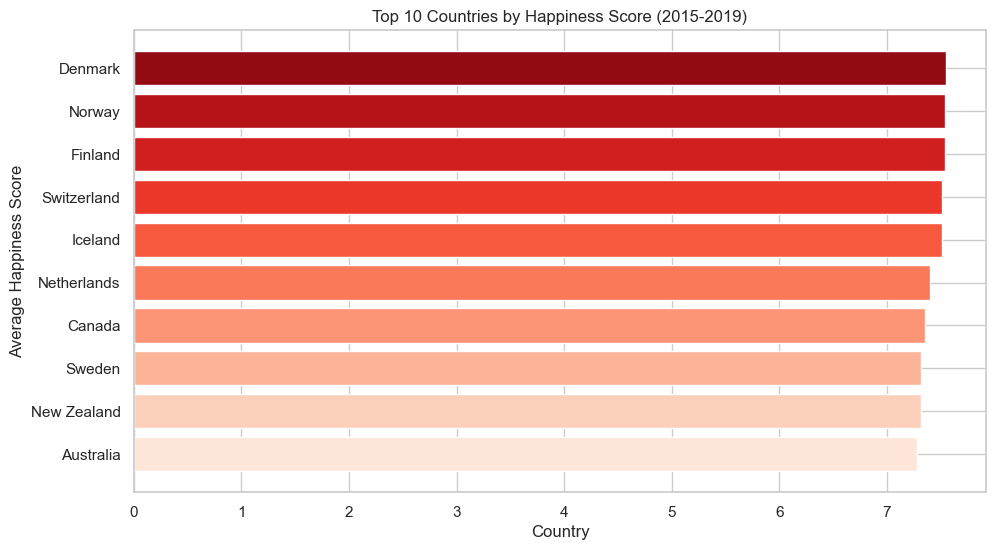

In [13]:
# --- Top 10 ---
top10_countries = world_happiness_df.groupby("country")["happiness_score"].mean().nlargest(10)
top10_df = top10_countries.reset_index() 
top10_df = top10_df.sort_values("happiness_score", ascending=True)

plt.barh(y=top10_df["country"],
         width=top10_df["happiness_score"],
         color=sns.color_palette("Reds", n_colors=10))

plt.title("Top 10 Countries by Happiness Score (2015-2019)")
plt.xlabel("Country")
plt.ylabel("Average Happiness Score")
plt.show()

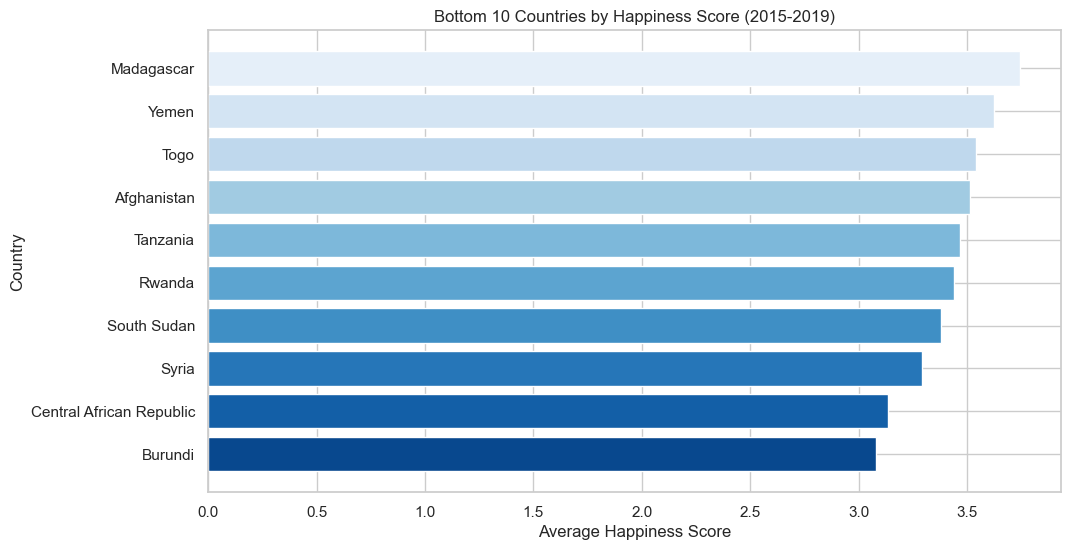

In [14]:
# --- Bottom 10 ---
bottom10_countries = world_happiness_df.groupby("country")["happiness_score"].mean().nsmallest(10)
bottom10_df = bottom10_countries.reset_index()
bottom10_df = bottom10_df.sort_values("happiness_score", ascending=True)  

plt.barh(y=bottom10_df["country"],
         width=bottom10_df["happiness_score"],
         color=sns.color_palette("Blues_r", n_colors=10))
plt.title("Bottom 10 Countries by Happiness Score (2015-2019)")

plt.xlabel("Average Happiness Score")
plt.ylabel("Country")
plt.show()

**Interpretation:** Highest: Denmark Lowest Burundi

---
### Q2. What does the overall distribution of Happiness Scores look like across all countries? Is it roughly normal, or skewed?

**Your chart choice:** *(write your reasoning here before coding)*

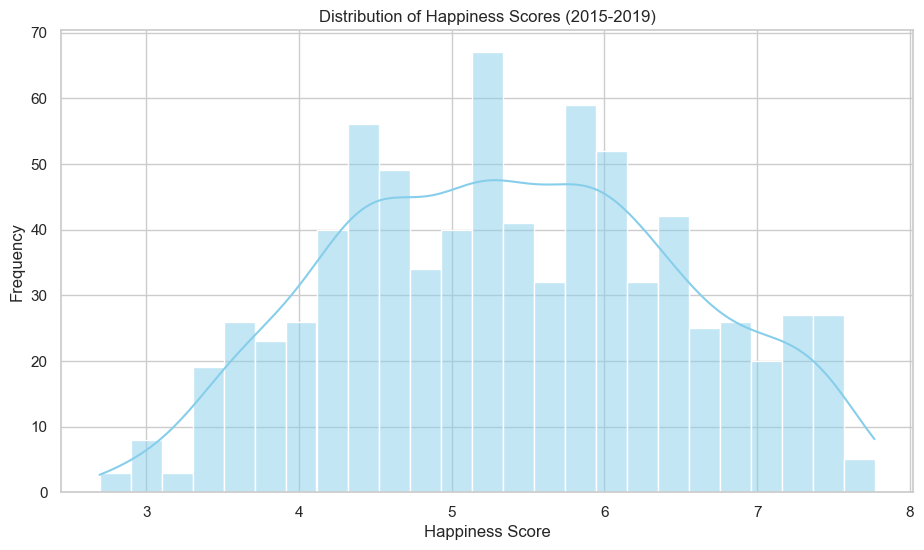

In [15]:
sns.histplot(
    world_happiness_df['happiness_score'],
    bins=25,
    color='skyblue',
    kde=True,
)

plt.title("Distribution of Happiness Scores (2015-2019)")
plt.xlabel("Happiness Score")
plt.ylabel("Frequency")
plt.show()

---
### Q3. Is there a relationship between GDP per Capita and Happiness Score?

**Your chart choice:** Scatter plot was the choice of graph here as it shows correlation between two bariables and easy to see by the distribution whether its strong, weak, positive, negative or no correlation

Text(0, 0.5, 'Happiness Score')

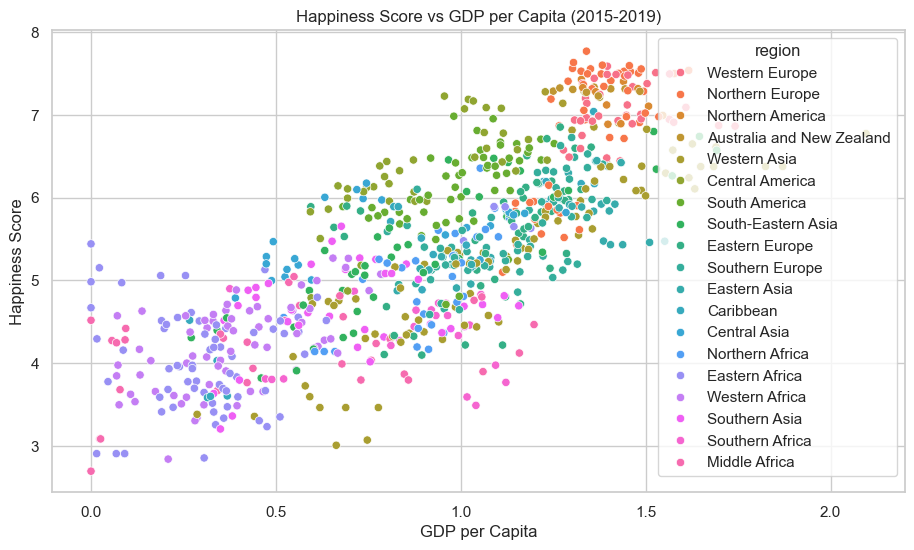

In [16]:
# Your code here
# Tip: colour each point by Region to add a third dimension without needing a second chart
# Tip: adding a regression line (sns.regplot or sns.lmplot) makes the trend clearer
from pyparsing import line


sns.scatterplot(
    data = world_happiness_df,
    x = 'gdp_per_capita',
    y = 'happiness_score',
    hue = 'region',
)

plt.title("Happiness Score vs GDP per Capita (2015-2019)")
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")


**Interpretation:** Strong positive correlation between GDP per Capita and Happiness Score 

---
### Q4. What proportion of countries in the dataset come from each world region?

**Your chart choice:** *(write your reasoning here before coding)*

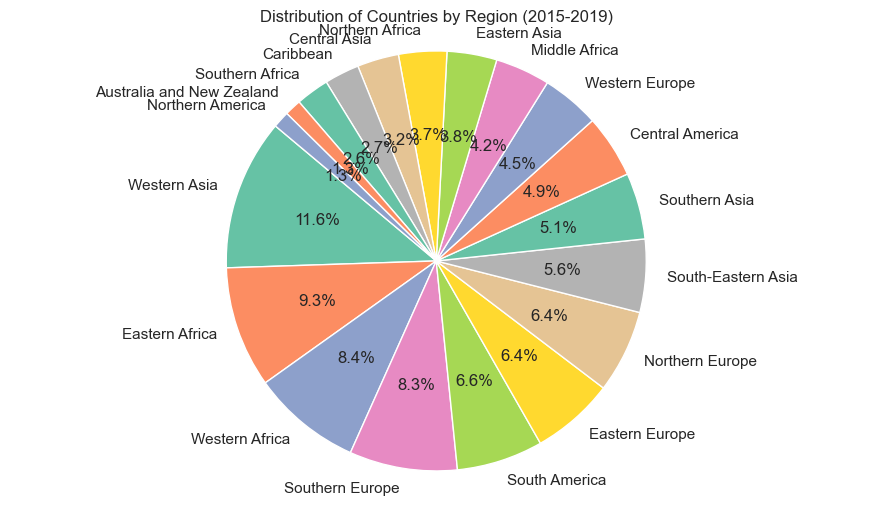

In [17]:
region_counts = world_happiness_df['region'].value_counts()
plt.pie(
    region_counts,
    labels=region_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("Set2", n_colors=len(region_counts))
)

plt.title("Distribution of Countries by Region (2015-2019)")
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular.
plt.show()

**Interpretation:** Western Asia holds the greatest proportion of countried by region.

---
### Q5. How does the spread and distribution of Happiness Scores vary across different world regions?

**Your chart choice:**  Box Plot and Violin Plot

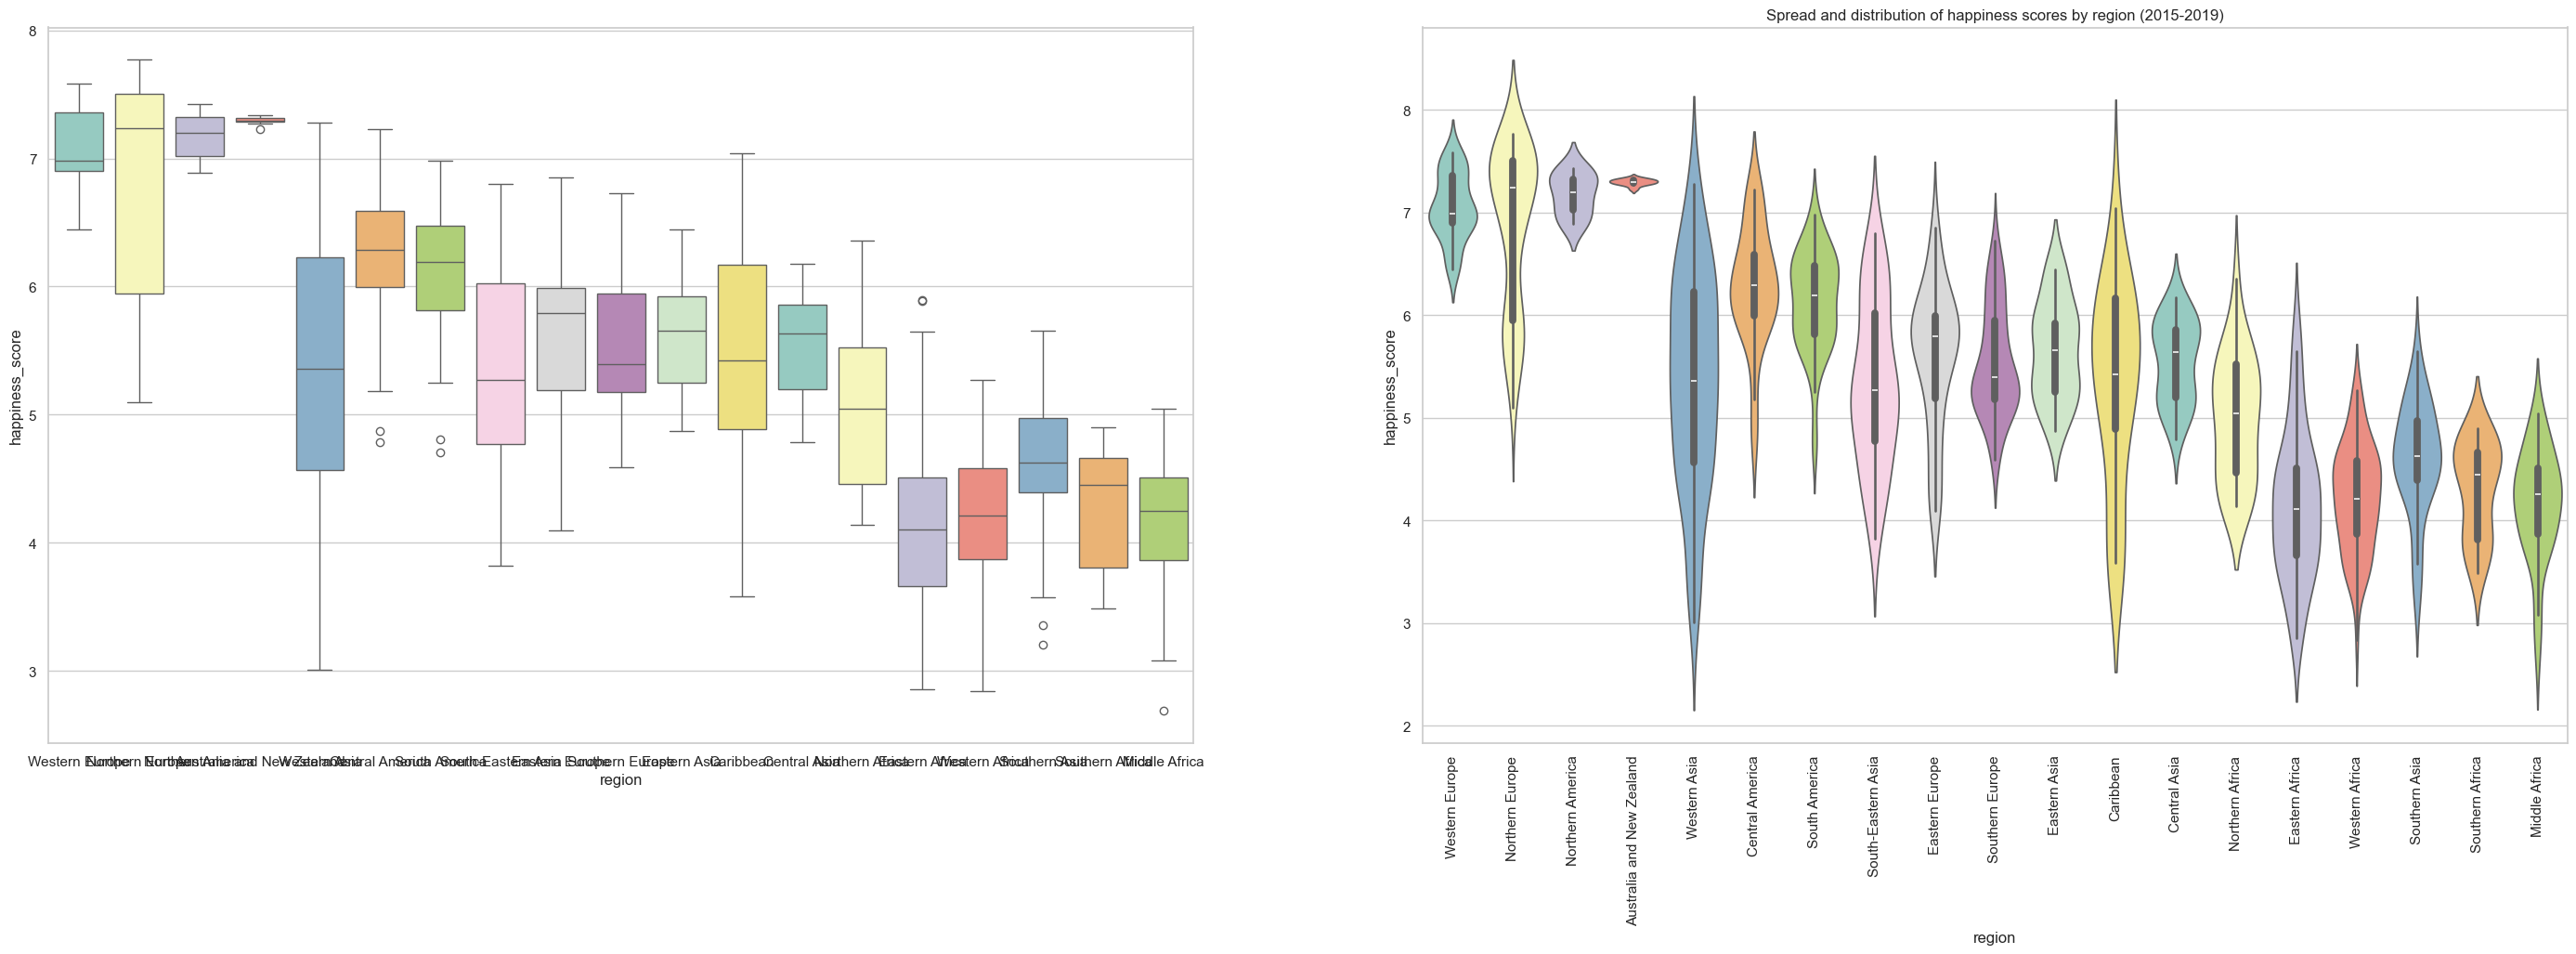

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(35,10))

#Box plot of happiness scores by region
sns.boxplot(
    data=world_happiness_df,
    x='region',
    y='happiness_score',
    palette='Set3',
    ax=axes[0]
)

plt.title('Spread and distribution of happiness scores by region (2015-2019)')
plt.xticks(rotation=90)

#Violin plot of happiness scores by region 
sns.violinplot(
    data=world_happiness_df,
    x='region',
    y='happiness_score',
    palette='Set3',
    ax=axes[1]
)

plt.title('Spread and distribution of happiness scores by region (2015-2019)')
plt.xticks(rotation=90)
plt.show()

---
### Q6. How do all the numeric features (GDP, Social Support, Life Expectancy, Freedom, Generosity, Corruption) correlate with each other and with Happiness Score?

**Your chart choice:** *(write your reasoning here before coding)*

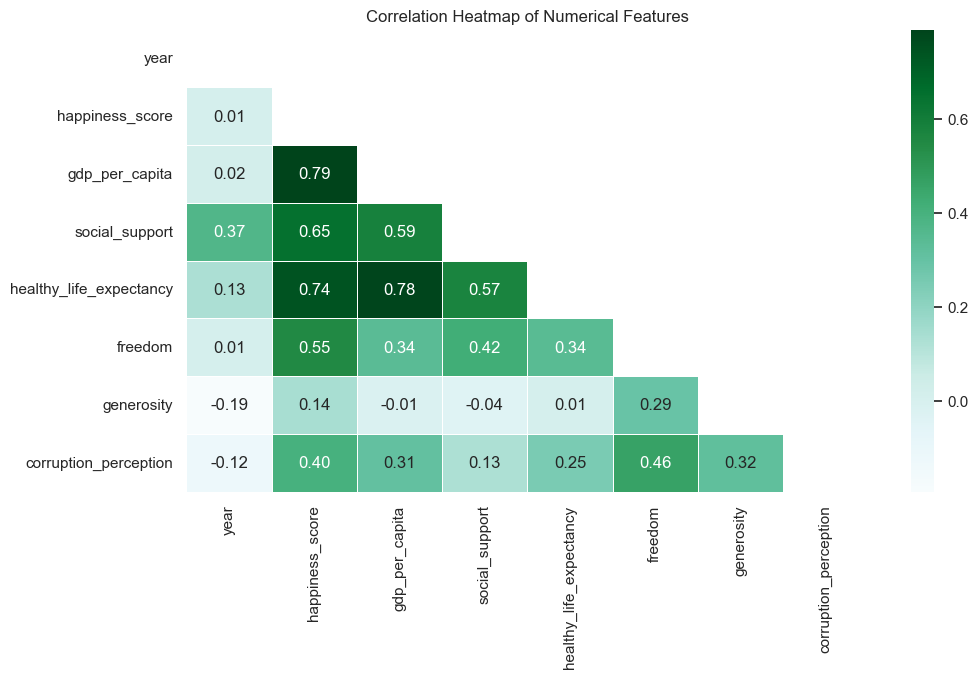

In [ ]:
#Correlation heatmap of all numerical features 
numerical_cols = world_happiness_df.select_dtypes(include=np.number).columns.tolist() #Select only numerical columns for correlation
mask = np.zeros_like(world_happiness_df[numerical_cols].corr()) #Create a mask of zeros with the same shape as the correlation matrix
mask[np.triu_indices_from(mask)] = True #Set the upper triangle of the mask to True, which will hide those values in the heatmap

with sns.axes_style("white"):
    ax = sns.heatmap(
        world_happiness_df[numerical_cols].corr(), 
        mask=mask, 
        cmap='BuGn', 
        annot=True, 
        fmt='.2f', 
        linewidths=0.5)
     
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

**Interpretation:** GDP Per capital shows the strongest positive correlation with happiness score, followed by healthy life expectancy 

---
### Q7. *(Multi-year version only)* How has the average global Happiness Score changed year on year?

**Your chart choice:** Line chart: good choice for analysisng trends over time

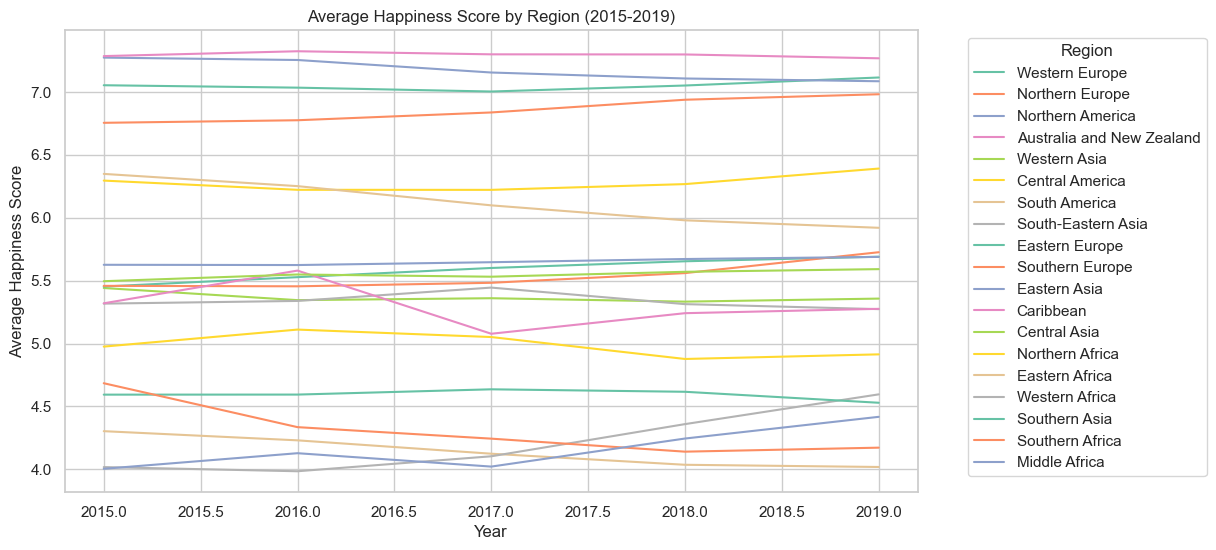

In [20]:
#stacked area chart of average happiness score by region year on year

sns.lineplot(
    data=world_happiness_df,
    x='year',
    y='happiness_score',
    hue='region',
    estimator='mean',
    ci=None,
    palette='Set2'
)
plt.title("Average Happiness Score by Region (2015-2019)")
plt.xlabel("Year")
plt.ylabel("Average Happiness Score")
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Interpretation:** Australia and New zealand has seen the highest avergae year on year showing a relatively stable consistency. Western Africa has seen a stark rise since the year 2017 similarly to middle africa. Conversly, South America and Northern Africa have both seen declining averages in Happiness score

---
### Q8. Among the top 10 happiest countries, how does each happiness sub-factor (GDP, Social Support, Freedom, etc.) contribute to their total score?

**Your chart choice:** *(write your reasoning here before coding)*

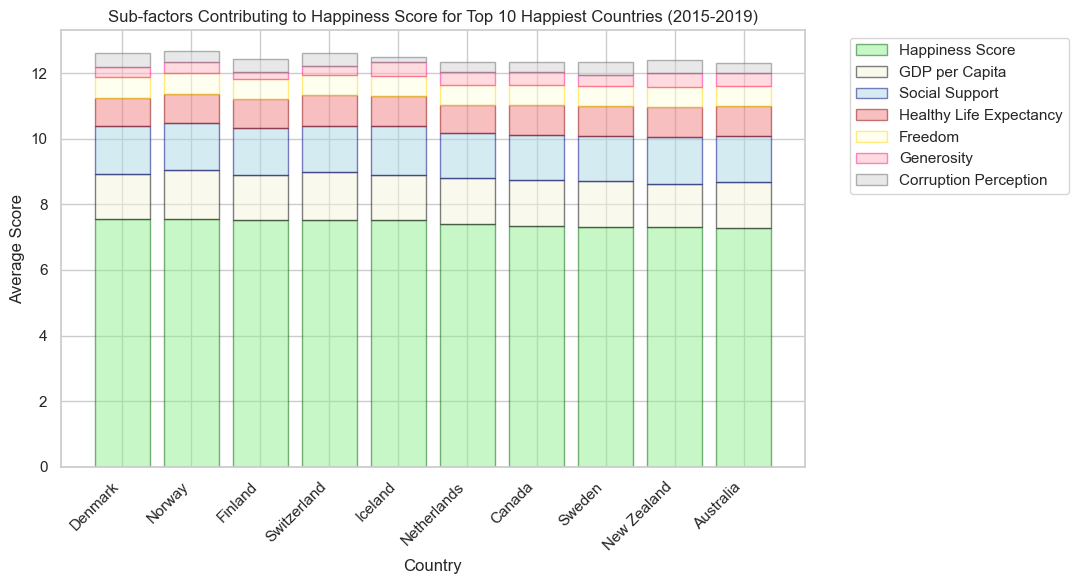

In [21]:
#stacked bar chart of different sub-factors contributing to happiness score for the top10 happiest countries 
cols = ['happiness_score', 'gdp_per_capita', 'social_support', 
        'healthy_life_expectancy', 'freedom', 'generosity', 'corruption_perception']

top10_df = world_happiness_df.groupby("country")[cols].mean()
top10_df = top10_df.nlargest(10, "happiness_score")
top10_df = top10_df.sort_values("happiness_score", ascending=False)
top10_df = top10_df.reset_index()

plt.bar(range(len(top10_df)), top10_df['happiness_score'], color='lightgreen',edgecolor='darkgreen', alpha=0.5, label='Happiness Score')
plt.bar(range(len(top10_df)), top10_df['gdp_per_capita'], color='beige', edgecolor='black', alpha=0.5, label='GDP per Capita', bottom=top10_df['happiness_score'])
plt.bar(range(len(top10_df)), top10_df['social_support'], color='lightblue', edgecolor='navy', alpha=0.5, label='Social Support', bottom=top10_df['happiness_score'] + top10_df['gdp_per_capita'])
plt.bar(range(len(top10_df)), top10_df['healthy_life_expectancy'], color='lightcoral', edgecolor='darkred', alpha=0.5, label='Healthy Life Expectancy', bottom=top10_df['happiness_score'] + top10_df['gdp_per_capita'] + top10_df['social_support'])
plt.bar(range(len(top10_df)), top10_df['freedom'], color='lightyellow', edgecolor='gold', alpha=0.5, label='Freedom', bottom=top10_df['happiness_score'] + top10_df['gdp_per_capita'] + top10_df['social_support'] + top10_df['healthy_life_expectancy'])
plt.bar(range(len(top10_df)), top10_df['generosity'], color='lightpink', edgecolor='deeppink', alpha=0.5, label='Generosity', bottom=top10_df['happiness_score'] + top10_df['gdp_per_capita'] + top10_df['social_support'] + top10_df['healthy_life_expectancy'] + top10_df['freedom'])
plt.bar(range(len(top10_df)), top10_df['corruption_perception'], color='lightgray', edgecolor='dimgray', alpha=0.5, label='Corruption Perception', bottom=top10_df['happiness_score'] + top10_df['gdp_per_capita'] + top10_df['social_support'] + top10_df['healthy_life_expectancy'] + top10_df['freedom'] + top10_df['generosity'])

plt.xticks(range(len(top10_df)), top10_df['country'], rotation=45, ha='right')
plt.title("Sub-factors Contributing to Happiness Score for Top 10 Happiest Countries (2015-2019)")
plt.xlabel("Country")
plt.ylabel("Average Score")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

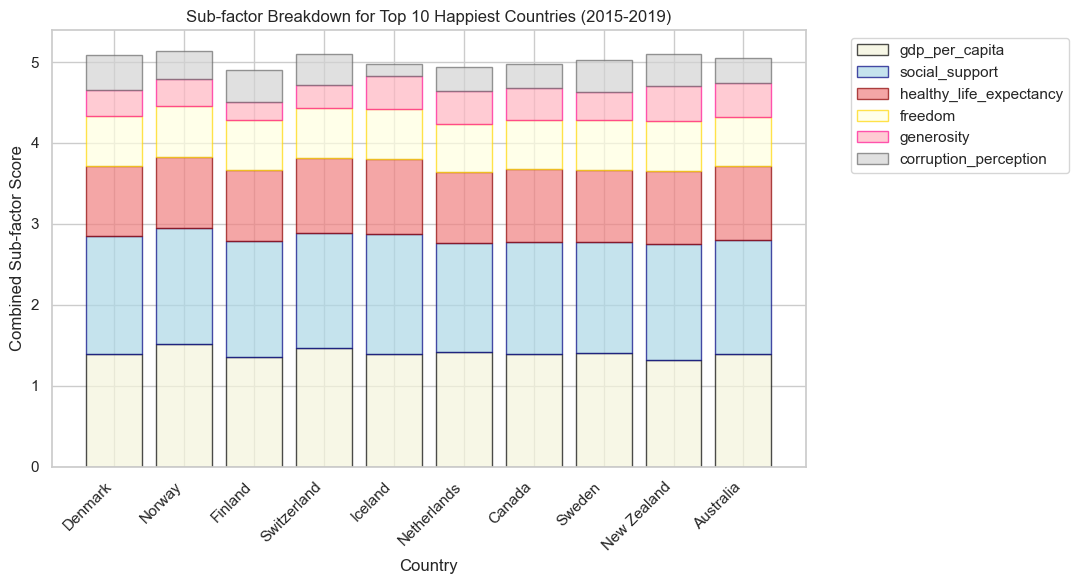

In [22]:
sub_factors = ['gdp_per_capita', 'social_support', 'healthy_life_expectancy', 
               'freedom', 'generosity', 'corruption_perception']

bottom = pd.Series([0] * len(top10_df))
colors = ['beige', 'lightblue', 'lightcoral', 'lightyellow', 'lightpink', 'lightgray']
edges = ['black', 'navy', 'darkred', 'gold', 'deeppink', 'dimgray']

for col, color, edge in zip(sub_factors, colors, edges):
    plt.bar(range(len(top10_df)), 
            top10_df[col], 
            bottom=bottom,
            color=color, 
            edgecolor=edge, 
            alpha=0.7, 
            label=col)
    bottom += top10_df[col].values

plt.xticks(range(len(top10_df)), top10_df['country'], rotation=45, ha='right')
plt.title("Sub-factor Breakdown for Top 10 Happiest Countries (2015-2019)")
plt.xlabel("Country")
plt.ylabel("Combined Sub-factor Score")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**Interpretation:** *(one sentence)*

---
### Q9. What are the pairwise relationships between all numeric features simultaneously, and do regional clusters emerge?

**Your chart choice:** Paiplot shows relationship pairwise relationships between features

<Figure size 1200x800 with 0 Axes>

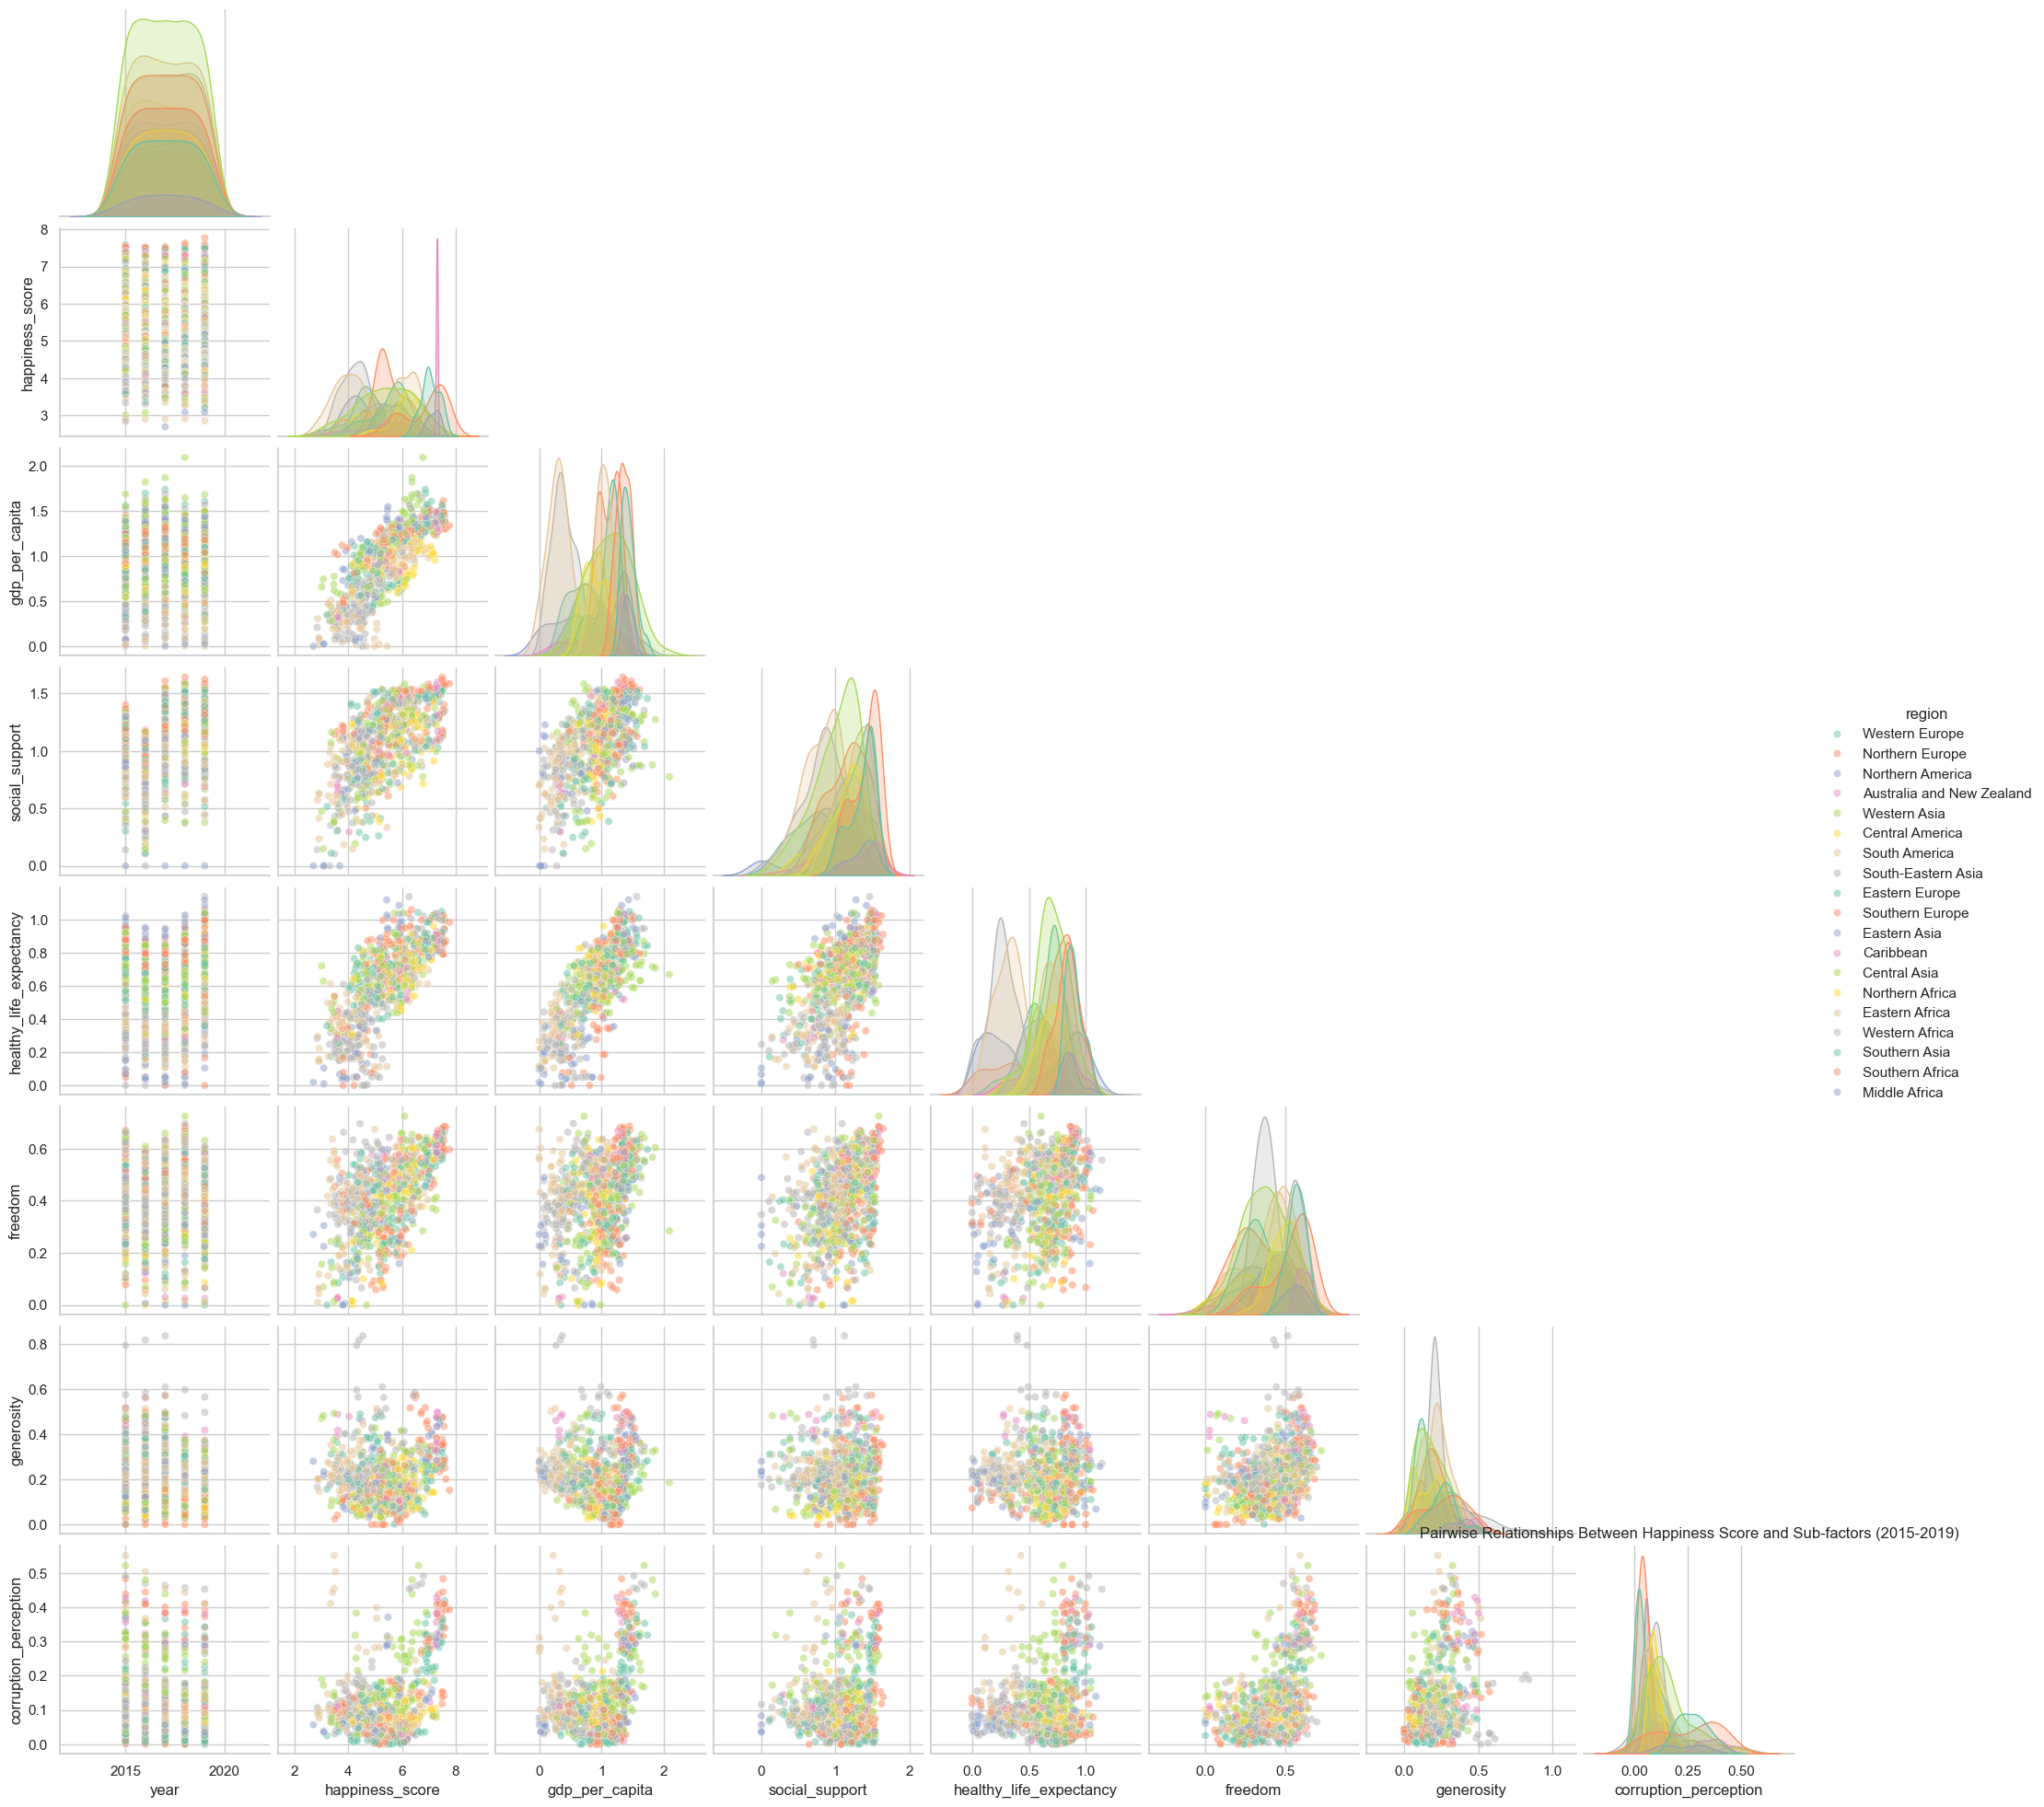

In [23]:
plt.figure(figsize=(12, 8))

sns.pairplot(
    data=world_happiness_df,
    vars=numerical_cols,
    hue='region',
    palette='Set2',
    plot_kws={'alpha': 0.5},
    corner=True
)

plt.title("Pairwise Relationships Between Happiness Score and Sub-factors (2015-2019)")
plt.show()


---
### Q10. [BONUS] Is there a relationship between a country's perceived freedom and its generosity score? Does this differ by region?

**Your chart choice:** *(write your reasoning here before coding)*

In [24]:
#Is there a relationship between a countries percieved freedom and its generosity?
"""sns.FacetGrid(
    data=world_happiness_df,
    row='freedom',
    col='generosity',
    hue='region',
    palette='Set2',
    height=6,
    aspect=1.5
).map(sns.scatterplot, alpha=0.7).add_legend()
    

plt.subplots_adjust(top=0.9)
plt.suptitle("Relationship Between Percieved Freedom and its Genorisity by Region (2015-2019)")
plt.show()
"""

'sns.FacetGrid(\n    data=world_happiness_df,\n    row=\'freedom\',\n    col=\'generosity\',\n    hue=\'region\',\n    palette=\'Set2\',\n    height=6,\n    aspect=1.5\n).map(sns.scatterplot, alpha=0.7).add_legend()\n    \n\nplt.subplots_adjust(top=0.9)\nplt.suptitle("Relationship Between Percieved Freedom and its Genorisity by Region (2015-2019)")\nplt.show()\n'

**Interpretation:** *(one sentence)*

---
# 🔍 SECTION 2 — EDA Practice

### How this section works

This section is about **building the habit of generating good analytical questions** before you reach for code.

Read the heuristics below carefully first. Then, looking at the column list from your `df.info()` output above, write your own EDA questions in the space provided. Investigate each one with code and note what you found.

---

### 🧠 EDA Question Heuristics — Read before writing your questions

Good EDA questions fall into **five categories**. Aim for at least one per category:

| Category | Template | What it reveals |
|---|---|---|
| **Distribution** | *What does the distribution of [variable] look like?* | Shape, skew, modality, outliers |
| **Outliers / Anomalies** | *Are there unusual or unexpected values in [variable]?* | Data quality issues, extreme cases |
| **Relationships** | *Does [variable A] increase/decrease as [variable B] increases?* | Correlations, hypotheses |
| **Group differences** | *Does [metric] differ meaningfully across [region/category]?* | Segmentation, inequality |
| **Temporal / Sequential** | *How has [variable] changed over time?* | Trends, shifts, events |

> **Sparks for this dataset specifically — things worth interrogating:**
> - Generosity is often the weakest predictor of happiness — is that true here?
> - Is corruption perception more important in some regions than others?
> - Are there countries that score much higher or lower on happiness than their GDP would predict?
> - Does Social Support or Freedom matter more once you control for wealth?
> - Which countries have moved the most in happiness rank over the years (if multi-year)?
> - Are there any features with suspicious concentrations of near-zero values?

---

### ✏️ Write your EDA questions here

Look at the data. Think about what genuinely interests or puzzles you. Fill in at least one per category — your own wording, not recycled from Section 1.

**Distribution questions:**
1. *(your question here)*
2. *(your question here)*

**Outlier / Anomaly questions:**
1. *(your question here)*
2. *(your question here)*

**Relationship questions:**
1. *(your question here)*
2. *(your question here)*

**Group difference questions:**
1. *(your question here)*
2. *(your question here)*

**Temporal / Sequential questions (skip if single-year):**
1. *(your question here)*

---
### 🔬 Investigate your questions

For each question above, use a code cell to investigate it. Write a **Finding** underneath each one — note whether the result confirmed your expectation, contradicted it, or raised a new question.

#### EDA Question 1 — *(paste your question here)*

In [25]:
# Your investigation here


**Finding:** *(what did you find? did it match your expectation? does it raise a follow-up question?)*

#### EDA Question 2 — *(paste your question here)*

In [26]:
# Your investigation here


**Finding:** *(what did you find? did it match your expectation? does it raise a follow-up question?)*

#### EDA Question 3 — *(paste your question here)*

In [27]:
# Your investigation here


**Finding:** *(what did you find? did it match your expectation? does it raise a follow-up question?)*

#### EDA Question 4 — *(paste your question here)*

In [28]:
# Your investigation here


**Finding:** *(what did you find? did it match your expectation? does it raise a follow-up question?)*

#### EDA Question 5 — *(paste your question here)*

In [29]:
# Your investigation here


**Finding:** *(what did you find? did it match your expectation? does it raise a follow-up question?)*

#### EDA Question 6 — *(paste your question here)*

In [30]:
# Your investigation here


**Finding:** *(what did you find? did it match your expectation? does it raise a follow-up question?)*